In [1]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

## Define helpers and functions

In [2]:
def reject_outliers(X, m=3, scaling=False):
    """
    Adapted from https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    Returns a boolean mask where True = 'Keep' and False = 'Outlier'.
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')

    if scaling:
        mad = np.median(np.abs(X - median), axis=0) * 1.4826
    else:
        mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    mask = (X >= lower_bound) & (X <= upper_bound)

    return mask


def reject_outliers_by_subject_channel(burst_dict, value_key='peak_amp_base', m=3, scaling=False):
    """Compute outlier mask separately within each subject x chennel group.

    Args:
        burst_dict (dictionary): Burst dictionary containing at least:
            - 'subject'
            - 'channel'
            - value_key
        
        value_key (str, optional): Name of the feature on which to reject outliers. Defaults to 'peak_amp_base'.
        m (float, optional): Number of MADs from the median used as the cutoff. Defaults to 3.
        scaling (bool, optional): If True, scale MAD by 1.4826. Defaults to False.
    
    Returns:
        group_mask: ndarray of bool, shape (n_bursts,). Global mask with True = keep, False = outlier.
    """

    values = np.asarray(burst_dict[value_key])
    subjects_arr = np.asarray(burst_dict['subject'])
    channels_arr = np.asarray(burst_dict['channel'])

    n = len(values)
    if not (len(subjects_arr) == n and len(channels_arr) == n):
        raise ValueError(f"'subject', 'channel', and '{value_key}' must have the same length." )
    
    group_mask = np.ones(n, dtype=bool)
    unique_subjects = np.unique(subjects_arr)

    for sub in unique_subjects:
        sub_idx = subjects_arr == sub
        sub_channels = np.unique(channels_arr[sub_idx])

        for ch in sub_channels:
            idx = sub_idx & (channels_arr == ch)

            # Reject within this subject x channel subset
            local_mask = reject_outliers(values[idx], m=m, scaling=scaling)

            # Write local decisions back into full-length mask
            group_mask[idx] = local_mask

    return group_mask

In [3]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

In [4]:
def get_features_and_labels(gcPC_scores, bursts_dict, type_subs, cols_idx, n_bins, area):
    """
    Function to build the feature matrix and label vector for the logistic regression classifier.
    It takes as input the gcPC scores for all bursts, the bursts dictionary, the indices of the gcPCs
    to consider, the number of bins to use for each gcPC, the number of MADs to use for outlier
    rejection when building trial-level features, and the area to consider (STN or cortical).
    """
    
    max_type_subs = sum(len(np.unique(bursts_dict['trial'][bursts_dict['subject'] == sub])) for sub in type_subs)
    X = np.zeros((max_type_subs, len(cols_idx) * n_bins))
    y = np.zeros(max_type_subs)

    r = 0
    for i in range(len(type_subs)):
        type_sub = type_subs[i]
        
        # compute percentile bin limits using subject bursts only
        subject_bursts_idx = (bursts_dict['subject'] == type_sub) & area
        if np.sum(subject_bursts_idx) == 0:
            print(f'Warning: No bursts found for subject {type_sub} in the selected area ({area}). '
                  'Skipping this subject for percentile bin limit computation.')
            continue

        pc_bin_lims = np.zeros((len(cols_idx), n_bins + 1))
        for col_idx, col in enumerate(cols_idx):
            pc_bin_lims[col_idx, :] = np.percentile(gcPC_scores[subject_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

        # Build trial-level features across all cortex trials
        trials = np.unique(bursts_dict['trial'][(bursts_dict['subject'] == type_sub)])
        for trial in trials:
            burst_idx = area & (bursts_dict['trial'] == trial) & (bursts_dict['subject'] == type_sub)
            label = np.unique(bursts_dict['med'][burst_idx])[0]
            
            row = np.zeros(len(cols_idx) * n_bins, dtype=float)  # Pre-allocate row with zeros for gcPC-bin combinations with no bursts
            for col_idx, col in enumerate(cols_idx):
                for bin in range(n_bins):
                    lower = pc_bin_lims[col_idx, bin]
                    higher = pc_bin_lims[col_idx, bin+1]
                    count = np.sum((gcPC_scores[burst_idx, col] >= lower) &
                                    (gcPC_scores[burst_idx, col] < higher))
                    row[col_idx * n_bins + bin] = count
            X[r, :] = row
            y[r] = 0 if label == 'OFF' else 1
            r += 1

    X = X[:r]
    y = y[:r]

    return X, y

## Data loading

### Channel labels

In [5]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [6]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [7]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


## Perform light pre-processing
* Redefine the trial indices ensuring they're not overlapping between ON and OFF medication - subject-level based
* Convert burst time to ms
* Reject outliers based on their peak amplitude

In [8]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

In [9]:
burst_times = all_bursts['waveform_times'] * 1000 

In [10]:
outlier_mask = reject_outliers_by_subject_channel(
    all_bursts,
    value_key='peak_amp_base',
    m=3,
    scaling=False
    )

len_mask = len(outlier_mask)

correct_bursts = {
    key: (value[outlier_mask] if len(value) == len_mask else value)
    for key, value in all_bursts.items()
    }

# print(f"Original trials: {len(all_bursts['peak_amp_base'])}")
# print(f"Corrected trials: {len(correct_bursts['peak_amp_base'])}")
# print(f"Removed trials: {len(all_bursts['peak_amp_base']) - len(correct_bursts['peak_amp_base'])}")

### Select bursts corresponding to C3/C4 and all STN contacts

In [11]:
c_idx = (correct_bursts['channel']=='C3') | (correct_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in correct_bursts['channel']]

In [12]:
on_idx = (correct_bursts['med']=='ON')
off_idx = (correct_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [13]:
"""
```scaling_method``` accepts: 
    - 'MAD-based',
    - 'Robust',
    - 'Standard'
"""
scaling_method = 'MAD-based'

area = stn_idx
scaled_waveforms = np.zeros_like(correct_bursts['waveform'])
for subject in np.unique(correct_bursts['subject']):
    subj_idx = (correct_bursts['subject'] == subject)

    if scaling_method == 'Robust':
        """Perform a modified z-score based on median and IQR"""
        scaler = RobustScaler().fit(correct_bursts['waveform'][subj_idx & area])                # .fit() returns the median and IQR values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'Standard':
        """Perform a z-score based on mean and STD"""
        scaler = StandardScaler().fit(correct_bursts['waveform'][subj_idx & area])              # .fit() returns the mean and STD values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'MAD-based':
        """Perfom a modified z-score based on median and MAD"""
        median, mad = scaler_fit(correct_bursts['waveform'][subj_idx & area])                   # Scaler based on MAD
        scaled_waveforms[subj_idx, :] = scaler_transform(correct_bursts['waveform'][subj_idx], median, mad)

    else:
        raise AttributeError("Wrong scaling method. Valide options are ['MAD-based', 'Robust', 'Standard'].")

## Group-level cross validation: split subjects into train/test groups
* 1/ Perfom rPCA
* 2/ Each PC is binned
* 3/ Compute logit on rPCA, taking number of PCs and bins as features

In [14]:
"""Parameters definition"""
n_bins = 3  # Number of bins to use for each gcPC
cols = np.arange(13)   # List of rPC axes to consider
m=3

subjects = np.array(subjects)
n_splits = len(subjects)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)

fold_scores = []
train_fold_scores = []

for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
    """Run cross-validation logits on PCA ouptuts"""
    
    train_subs = subjects[train_s_idx]
    test_subs = subjects[test_s_idx]

    # select bursts from training subjects (cortex channels only)
    train_bursts_idx = np.isin(correct_bursts['subject'], train_subs) & area

    # Fit PCA on training subjects' bursts
    pca_model = PCA(n_components=20, random_state=6)
    pca_model.fit(scaled_waveforms[train_bursts_idx, :])
    all_scores = scaled_waveforms @ pca_model.components_.T

    """Get features and labels for logit from gcPCA outputs"""
    X_train, y_train = get_features_and_labels(all_scores, correct_bursts, train_subs, cols, n_bins, area)
    X_test, y_test = get_features_and_labels(all_scores, correct_bursts, test_subs, cols, n_bins, area)

    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)

    """Logistic regression on gcPCA outputs with increased maximum iterations"""
    model = LOR(max_iter=10_000)
    model = model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    train_score = np.mean(y_train == y_train_pred)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    intercept = model.intercept_
    coefs = model.coef_
    print(f'Fold {fold_idx} Logistic Regression Coefficients:')
    for i, col in enumerate(cols):
        for bin in range(n_bins):
            print(f'  PC{col} Bin {bin}:\tCoef =\t {coefs[0][i*n_bins + bin]:.4f}')

    score = np.mean(y_test == y_pred)
    print(f'Fold {fold_idx}: Score = {score:.3f}, Training set score = {train_score:.3f}\n')
    # print('  train_subs:', train_subs)
    # print('  test_subs:', test_subs)
    # print(f'  X_train shape: {X_train.shape}')
    # print(f'  X_test shape: {X_test.shape}\n')

    """Store logit accuracy"""
    fold_scores.append(score)
    train_fold_scores.append(train_score)

print(f'Group-level CV: Mean Score = {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}, Train Mean Score = {np.mean(train_fold_scores):.3f}  ± {np.std(train_fold_scores):.3f}')

Fold 0 Logistic Regression Coefficients:
  PC0 Bin 0:	Coef =	 0.0809
  PC0 Bin 1:	Coef =	 0.1031
  PC0 Bin 2:	Coef =	 0.1161
  PC1 Bin 0:	Coef =	 0.2151
  PC1 Bin 1:	Coef =	 0.1312
  PC1 Bin 2:	Coef =	 0.0865
  PC2 Bin 0:	Coef =	 0.1030
  PC2 Bin 1:	Coef =	 0.0641
  PC2 Bin 2:	Coef =	 0.1346
  PC3 Bin 0:	Coef =	 0.0827
  PC3 Bin 1:	Coef =	 -0.0696
  PC3 Bin 2:	Coef =	 0.0063
  PC4 Bin 0:	Coef =	 0.1068
  PC4 Bin 1:	Coef =	 0.0385
  PC4 Bin 2:	Coef =	 0.1169
  PC5 Bin 0:	Coef =	 0.0016
  PC5 Bin 1:	Coef =	 -0.0326
  PC5 Bin 2:	Coef =	 -0.0015
  PC6 Bin 0:	Coef =	 -0.2973
  PC6 Bin 1:	Coef =	 -0.3079
  PC6 Bin 2:	Coef =	 -0.2641
  PC7 Bin 0:	Coef =	 -0.2751
  PC7 Bin 1:	Coef =	 -0.2592
  PC7 Bin 2:	Coef =	 -0.2684
  PC8 Bin 0:	Coef =	 0.1110
  PC8 Bin 1:	Coef =	 0.0760
  PC8 Bin 2:	Coef =	 0.1818
  PC9 Bin 0:	Coef =	 -0.1122
  PC9 Bin 1:	Coef =	 -0.1100
  PC9 Bin 2:	Coef =	 -0.0929
  PC10 Bin 0:	Coef =	 0.0434
  PC10 Bin 1:	Coef =	 0.0272
  PC10 Bin 2:	Coef =	 0.1422
  PC11 Bin 0:	Coef =

## Plot mean waveforms for each bin of each rPC, averaged across subjects (excluding or not the last left out)

C:\Users\Loquet Jeremie\AppData\Local\Temp\ipykernel_29844\2044018357.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(subjects))


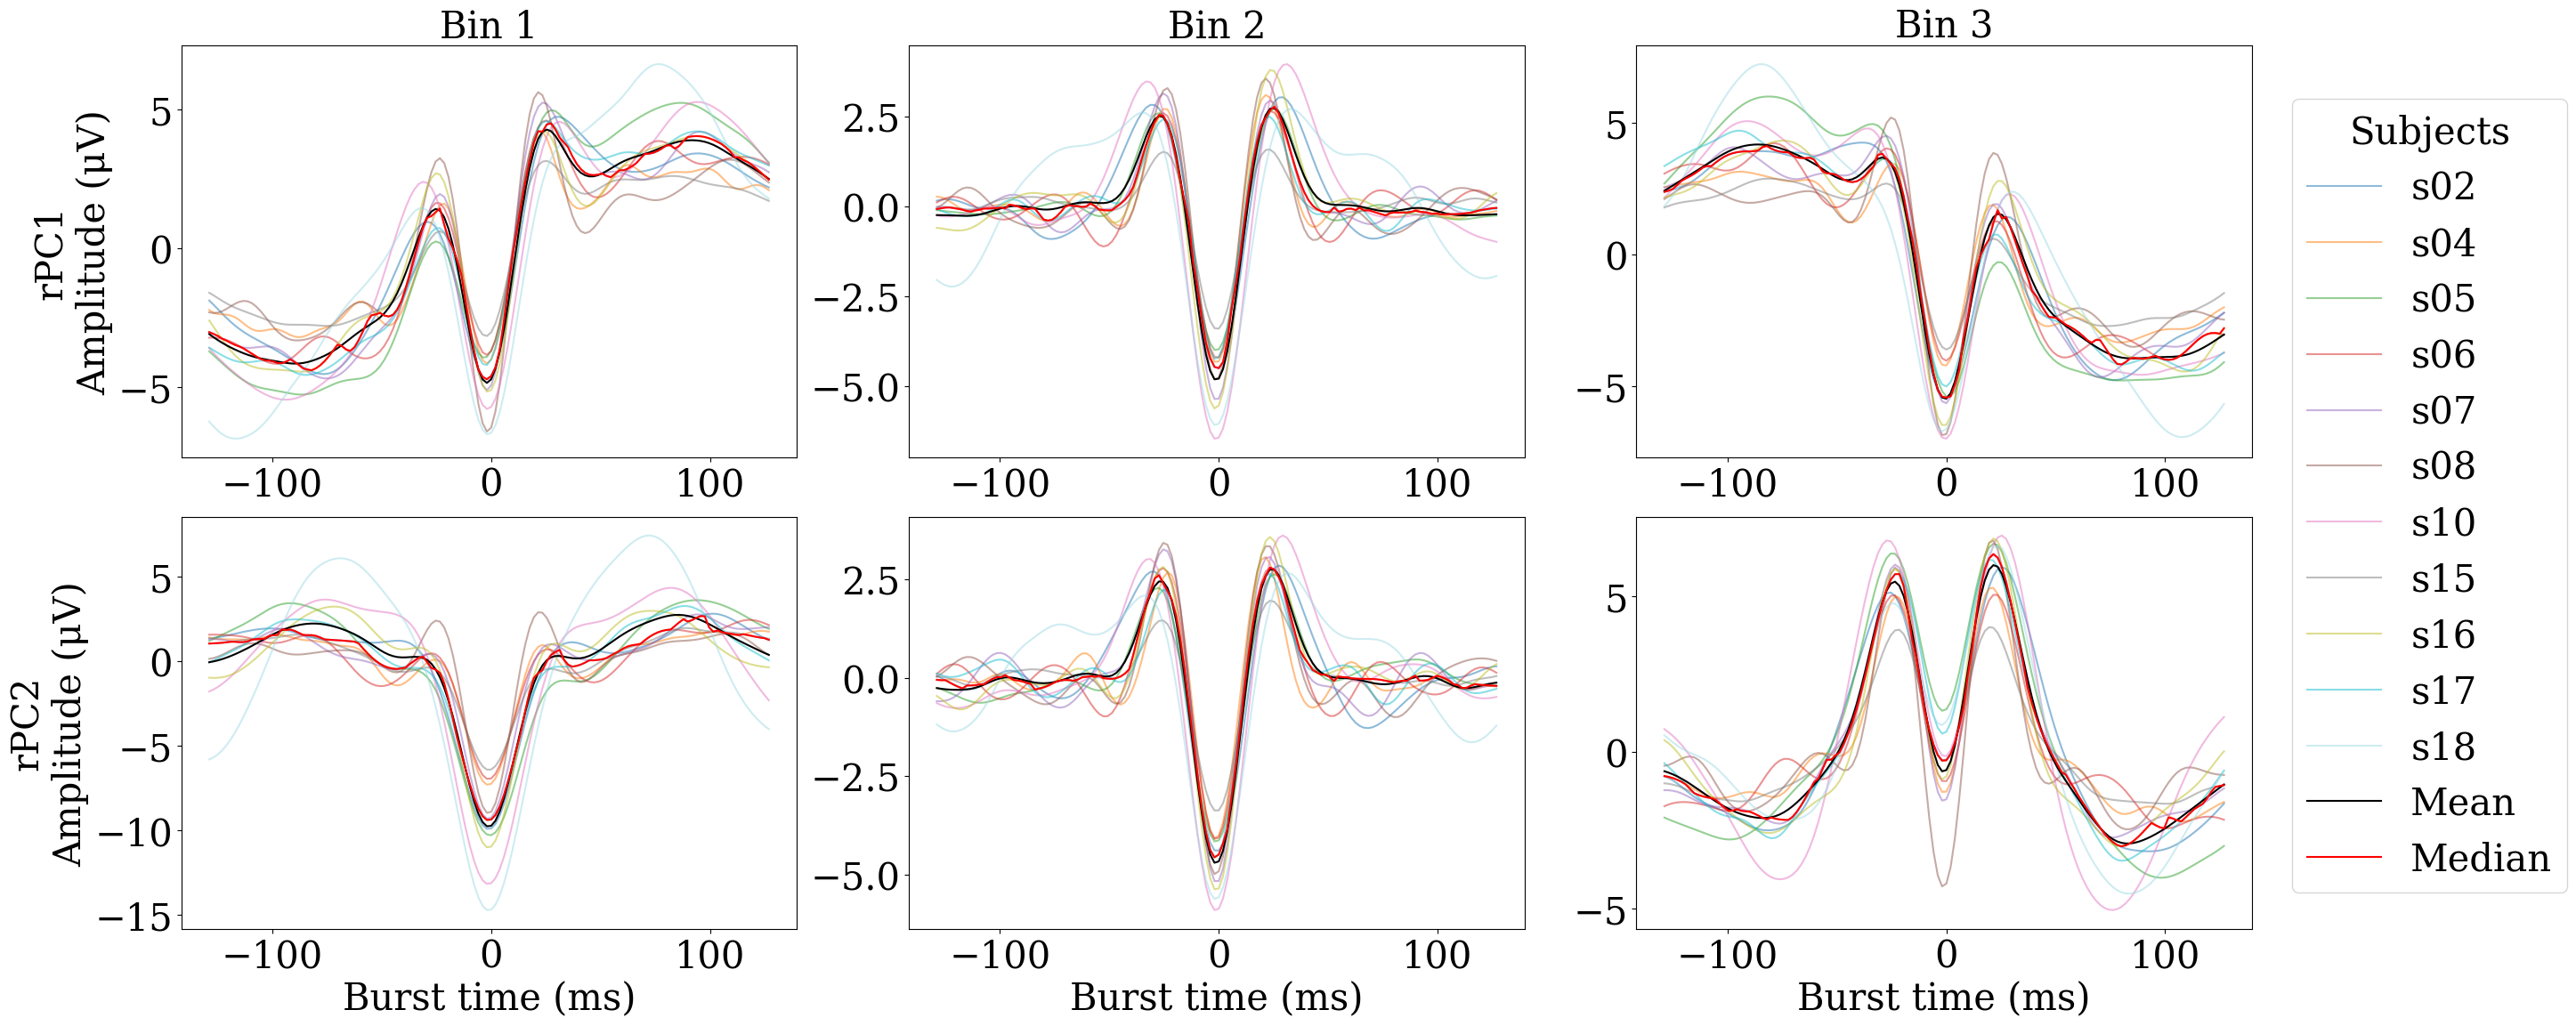

In [16]:
# Plot the mean waveforms for each bin of each rPC, averaged across subjects (excluding or not s18)
cols = [0, 1]

fig, ax = plt.subplots(len(cols), n_bins, figsize=(30, 12))

# Assign colors to subjects
cmap = plt.cm.get_cmap('tab20', len(subjects))
subject_colors = {sub: cmap(i) for i, sub in enumerate(subjects)}

labels = []

mean_waveforms = []  # for all subjects
for col in cols:
    bin_mean_waveforms = []  # reset for each col
    for bin in range(n_bins):
        sub_mean_waveforms = []  # for each bin
        for sub in subjects:  # [subjects != "s18"]
            sub_bursts_idx = np.isin(correct_bursts['subject'], sub) & area
            pc_bin_lims = np.percentile(all_scores[sub_bursts_idx, col], np.linspace(0, 100, n_bins + 1))
            
            if bin == (n_bins - 1):
                lims = (all_scores[:, col] >= pc_bin_lims[bin])
            else:
                lims = (all_scores[:, col] >= pc_bin_lims[bin]) & (all_scores[:, col] < pc_bin_lims[bin + 1])
            
            idx = (correct_bursts['subject'] == sub) & area & lims
            if np.sum(idx) > 0:  # check if there are bursts
                label = str(sub)
                if label not in labels:
                    labels.append(label)

                mean_sub_waveform = np.mean(correct_bursts['waveform'][idx, :], axis=0)
                ax[col, bin].plot(burst_times, mean_sub_waveform, color=subject_colors[sub], label=label, alpha=0.5)
                ax[col, bin].tick_params(axis='both', which='major', labelsize=30)
                sub_mean_waveforms.append(mean_sub_waveform)
        
        if sub_mean_waveforms:
            label_mean, label_median = "Mean", "Median"
            if label_mean not in labels:
                labels.append(label_mean)
            elif label_median not in labels:
                labels.append(label_median)

            overall_mean = np.mean(np.array(sub_mean_waveforms), axis=0)
            ax[col, bin].plot(burst_times, overall_mean, label=label_mean, color='black', alpha=1)
            bin_mean_waveforms.extend(sub_mean_waveforms)
            overall_median = np.median(np.array(sub_mean_waveforms), axis=0)
            ax[col, bin].plot(burst_times, overall_median, label=label_median, color='red', alpha=1)

        ax[0, bin].set_title(f'Bin {bin + 1}', fontsize=30)
        ax[len(cols)-1, bin].set_xlabel('Burst time (ms)', fontsize=30)

    if bin_mean_waveforms:
        mean_waveforms.append(np.mean(np.array(bin_mean_waveforms), axis=0))       

    ax[col, 0].set_ylabel(f'rPC{col+1}\nAmplitude (μV)', fontsize=30)

# Adjust subplots to make space for legend
fig.subplots_adjust(right=0.85)
fig.legend(labels=labels, bbox_to_anchor=(0.97, 0.89), title='Subjects', title_fontsize=30, fontsize=30)
# fig.suptitle('Mean Burst Waveforms by rPC Bin - MAD-based scaling', fontsize=30)
plt.tight_layout(rect=[0, 0, 0.85, 0.97])
plt.savefig('./plots/GL_rPCA-transformed_MAD-based_waveforms.png', dpi=300)
plt.savefig('./plots/GL_rPCA-transformed_MAD-based_waveforms.svg', format='svg')
plt.show()